# Pucktrick data quality


Thesis project

In [1]:
LOCAL_RUN = True  

PATH_IMG = "images"

if LOCAL_RUN:
    PATH = "DATASETS"
else:
    PATH = "file:///home/PuckTrickadmin/DATASETS"

In [2]:
MISSING_DATA_ALREADY_REMOVED = False
INF_DATA_ALREADY_REMOVED = False

SKIP_INTERMEDIATE_SAVE = False
null_count_features = 0

## 0. Notebook setup

In [3]:
!pip install -r requirements.txt
%pip install setuptools yellowbrick


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# import delle librerie necessarie
import numpy as np
import pandas as pd  # used for toPandas() visualization conversions
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Noto Sans Nabataean, Nimbus Sans, Nimbus Roman'
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, isnan
# split dataset in train and test set
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
# RFECV - no direct Spark equivalent; keeping sklearn for cross-validation strategies
from sklearn.model_selection import StratifiedKFold
import os
import glob
from sklearn.metrics import matthews_corrcoef, make_scorer
import seaborn as sns
import os
import subprocess
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql.functions import to_timestamp, date_format, hour, dayofweek, window, year
from pyspark.sql.functions import abs as spark_abs
from pyspark.sql.functions import col as _col

In [5]:
if(LOCAL_RUN):
    # Check Java installation
    java_home = os.environ.get('JAVA_HOME', '')
    if not java_home:
        # Try to find Java automatically
        try:
            java_path = subprocess.check_output(['which', 'java'], text=True).strip()
            java_home = os.path.dirname(os.path.dirname(os.path.realpath(java_path)))
            os.environ['JAVA_HOME'] = java_home
            print(f"Found Java at: {java_home}")
        except subprocess.CalledProcessError:
            print("Java not found! Please install Java 8 or 11.")
            print("Run: sudo apt install default-jdk")

    os.environ['PYSPARK_PYTHON'] = 'python3'
    os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

    # Initialize Spark session
    spark = SparkSession.builder \
        .appName("PucktrickDataQuality") \
        .master("local[*]") \
        .config("spark.driver.memory", "14g") \
        .config("spark.driver.host", "localhost") \
        .config("spark.ui.showConsoleProgress", "false") \
        .getOrCreate()

    print(f"Spark version: {spark.version}")

Found Java at: /usr/lib/jvm/java-11-openjdk


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/04 21:55:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [6]:
if not LOCAL_RUN:
    MASTER_URL   = "spark://10.0.1.8:7077"
    DRIVER_HOST  = "10.0.1.8"

    spark = SparkSession.builder \
        .appName("Cavas_Analysis") \
        .master(MASTER_URL) \
        .config("spark.submit.deployMode",      "client") \
        .config("spark.executor.instances",     "4") \
        .config("spark.executor.cores",         "4") \
        .config("spark.executor.memory",        "13g") \
        .config("spark.driver.memory",          "8g") \
        .config("spark.driver.host",            DRIVER_HOST) \
        .config("spark.driver.bindAddress",     DRIVER_HOST) \
        .config("spark.sql.shuffle.partitions", "32") \
        .getOrCreate()

    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession creata — versione:", spark.version)

## 1. Dataset Exploration

In [7]:
# Lettura del dataset con Spark
if not os.path.exists(f'{PATH}/all.parquet'):
    dataset = spark.read.csv(f'{PATH}/all.csv', header=True, inferSchema=True)
    # Salva il dataset in formato Parquet per un caricamento più veloce in futuro
    dataset.write.parquet(f'{PATH}/all.parquet', mode='overwrite')
else:
    dataset = spark.read.parquet(f'{PATH}/all.parquet')

26/03/04 21:56:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [8]:
# Mi salvo target e features in variabili diverse
uni_target = dataset.select('Label')
uni_target_generic = dataset.select('Label_generic')
uni_feature = dataset.drop('Label', 'Label_generic')

In [9]:
uni_feature.show(5)

+--------+--------+-------------------+-------------+------------+------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+----------------+----------------+----------------+----------------+------------+------------+-----------+------------+----------------+-----------+-----------+-----------+----------------+----------------+-----------+-----------+-------------+-------------+-------------+-------------+--------------+--------------+----------------+-------------+-----------+-----------+--------------+--------------+----------------+------------+------------+------------+------------+------------+------------+--------------+------------+-------------+--------------+----------------+----------------+--------------+--------------+----------------+--------------+--------------+----------------+----------------+----------------+----------------+----------------+----------

### 1.0. Dataset unification

Dataset was splitted into different CSVs. I had to unificate it into one sinfular file before splitting it into train and test.

In [10]:
skip_unification_dataset = True

In [11]:
if not skip_unification_dataset:
    # Leggi tutti i file CSV nella cartella "{PATH}"
    csv_files = [f for f in glob.glob(os.path.join('{PATH}', '*.csv')) if os.path.basename(f) != 'all.csv' and os.path.basename(f) != 'scrap.csv']

    output_path = '{PATH}/all.csv'
    scrap_path = '{PATH}/scrap.csv'

    # Rimuovi i file di output se esistono già
    for path in [output_path, scrap_path]:
        if os.path.exists(path):
            os.remove(path)

    # Le colonne di riferimento vengono prese dal primo file e non vengono mai cancellate
    reference_columns = None

    for i, f in enumerate(csv_files):
        df_chunk = pd.read_csv(f)

        if reference_columns is None:
            # Salva le colonne del primo file come riferimento
            reference_columns = df_chunk.columns.tolist()
            df_chunk.to_csv(output_path, mode='a', index=False, header=True)
        else:
            # Colonne in comune con il riferimento
            common_cols = [c for c in reference_columns if c in df_chunk.columns]
            # Colonne extra non presenti nel riferimento
            extra_cols = [c for c in df_chunk.columns if c not in reference_columns]

            # Scrivi le colonne comuni in all.csv
            df_common = df_chunk[common_cols]
            # Aggiungi colonne mancanti rispetto al riferimento come NaN
            for col in reference_columns:
                if col not in df_common.columns:
                    df_common[col] = np.nan
            df_common = df_common[reference_columns]
            df_common.to_csv(output_path, mode='a', index=False, header=False)
            del df_common

            # Scrivi le colonne extra in scrap.csv
            if extra_cols:
                df_scrap = df_chunk[extra_cols].copy()
                df_scrap.insert(0, 'source_file', os.path.basename(f))
                df_scrap.to_csv(scrap_path, mode='a', index=False, header=(not os.path.exists(scrap_path) or i == 1))
                del df_scrap

        # Pulisci la RAM (ma non reference_columns)
        del df_chunk

        print(f'[{i+1}/{len(csv_files)}] Processato: {f}')

    print(f'\nUniti {len(csv_files)} file CSV in "{output_path}"')
    print(f'Colonne di riferimento ({len(reference_columns)}): {reference_columns}')

notably one of the 10 days had 4 more features that were dropped into final dataset. Yet, to avoid losing the information the scrapped data was stored into 'scrap.csv' as those columns mmight have great relevance for our experiment. 
Later we'll see if we want to experiment with them or not.

### 1.1. Dataset dimensionality

In [12]:
# Mi salvo in una variabile il numero di features per dopo
n_features0 = len(dataset.columns) - 2 
# Sottraggo 2 perché tolgo la colonna "Label" e "Label_generic" che non sono feature ma target

# Stampo il numero di records e di features
print(f'There are {dataset.count()} instances \nand a total of {n_features0} features!')

There are 16233002 instances 
and a total of 79 features!


### 1.2. Unbalanced dataset

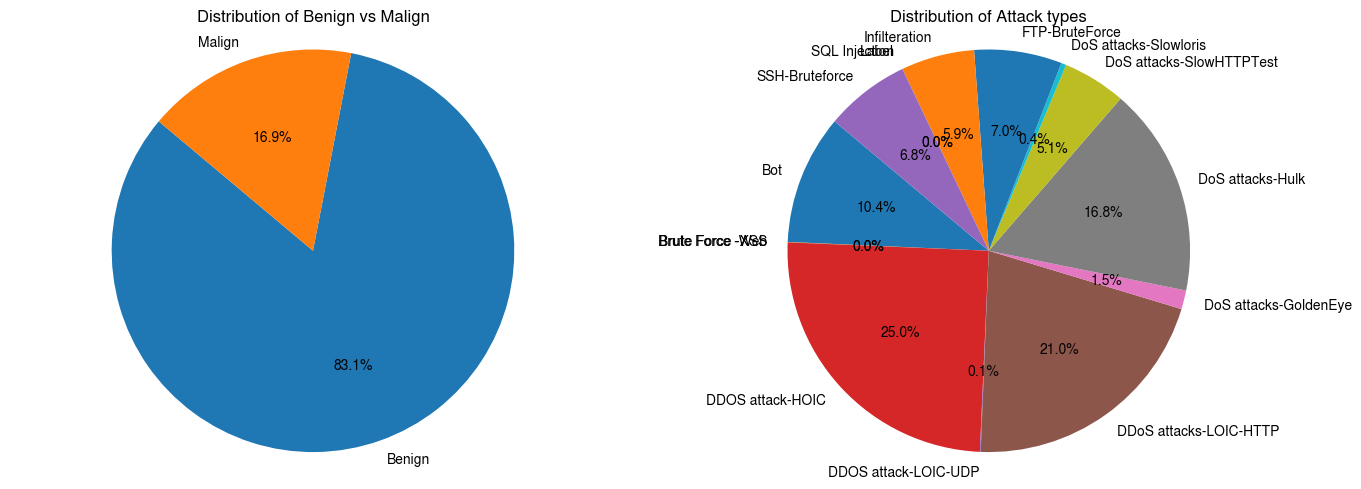

In [13]:
# Conta le occorrenze per ogni valore di Label e Label_generic
label_counts_pd = uni_target.groupBy('Label').count().orderBy('Label').toPandas()
label_generic_counts_pd = uni_target_generic.groupBy('Label_generic').count().orderBy('Label_generic').toPandas()

# Filtra label_counts per escludere Benign
label_counts_no_benign = label_counts_pd[label_counts_pd['Label'] != 'Benign']

# Visualizzali in due piechart affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(label_generic_counts_pd['count'], labels=['Benign', 'Malign'], autopct='%1.1f%%', startangle=140)
ax1.set_title('Distribution of Benign vs Malign')
ax1.axis('equal')

ax2.pie(label_counts_no_benign['count'], labels=label_counts_no_benign['Label'].astype(str), autopct='%1.1f%%', startangle=140)
ax2.set_title('Distribution of Attack types')
ax2.axis('equal')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/label_distribution_piecharts.png')
plt.show()

As we can see, the dataset is clearly very unbalanced. To try even the playing field for both positive (malign package) and negative (benign) can added a second target column that classifies all kinds of attacks as simply 'Malign'; having:
- first target: benign - malign (0-1)
- second target: bening - all other error subclasses 

This way, we can analyze a much more interesting case study! We will use a model capable of predicting two labels and then we'll be able to:

- First, we will observe how the prediction performance of the first label decreases depending on how much we corrupt the various features.
- Second, when the first prediction remains correct (despite the introduction of errors in the dataset), we can examine how the modification has led the model to hallucinate one type of attack rather than another.


### 1.3. Temporal distribution of label

In [14]:
# ── Timeline: conteggio Benign vs Malign per finestra temporale ──
img_path_temporal = f'{PATH_IMG}/temporal_distribution_label_generic.png'

qui ci si rende conto che la data viene interpretata come stringa quindi la si corregge

In [15]:
if not os.path.exists(img_path_temporal):
    # 1. Scopri i valori effettivi di Label_generic
    label_gen_values = [0,1]
    # Mapping: Label_generic è numerico (0=Benign, 1=Malign)
    BENIGN_LABEL = 0
    MALIGN_LABEL = 1
    LABEL_NAMES = {BENIGN_LABEL: 'Benign', MALIGN_LABEL: 'Malign'}

    # 2. Parsing del Timestamp — sovrascriviamo la colonna originale
    ts_col_type = dict(dataset.dtypes).get('Timestamp', 'unknown')
    print(f"Timestamp column type: {ts_col_type}")

    if ts_col_type in ('timestamp', 'date'):
        pass  # già nel formato corretto
    else:
        for fmt in ['yyyy-MM-dd HH:mm:ss', 'dd/MM/yyyy HH:mm:ss', 'MM/dd/yyyy HH:mm', 'dd/MM/yyyy H:mm', None]:
            dataset_tmp = dataset.withColumn('Timestamp', to_timestamp(col('Timestamp'), fmt) if fmt else to_timestamp(col('Timestamp')))
            ok = dataset_tmp.filter(col('Timestamp').isNotNull()).count()
            if ok > 0:
                dataset = dataset_tmp
                print(f"  Format '{fmt}' → parsed {ok}/{dataset.count()}")
                break

    # 3. Rimuovo dal dataset le righe con timestamp corrotti (1970/epoch) 
    count_before = dataset.count()
    dataset = dataset.filter((col('Timestamp').isNotNull()) & (year('Timestamp') >= 2018))
    count_after = dataset.count()
    discarded = count_before - count_after

    print(f"\nRemoved {discarded} rows with corrupted timestamps (epoch/1970 dates)")
    print(f"   Dataset: {count_before} → {count_after} rows")

    # ts_df punta allo stesso dataset ora pulito
    ts_df = dataset

    dataset.write.parquet(f'{PATH}/all.parquet', mode='overwrite')

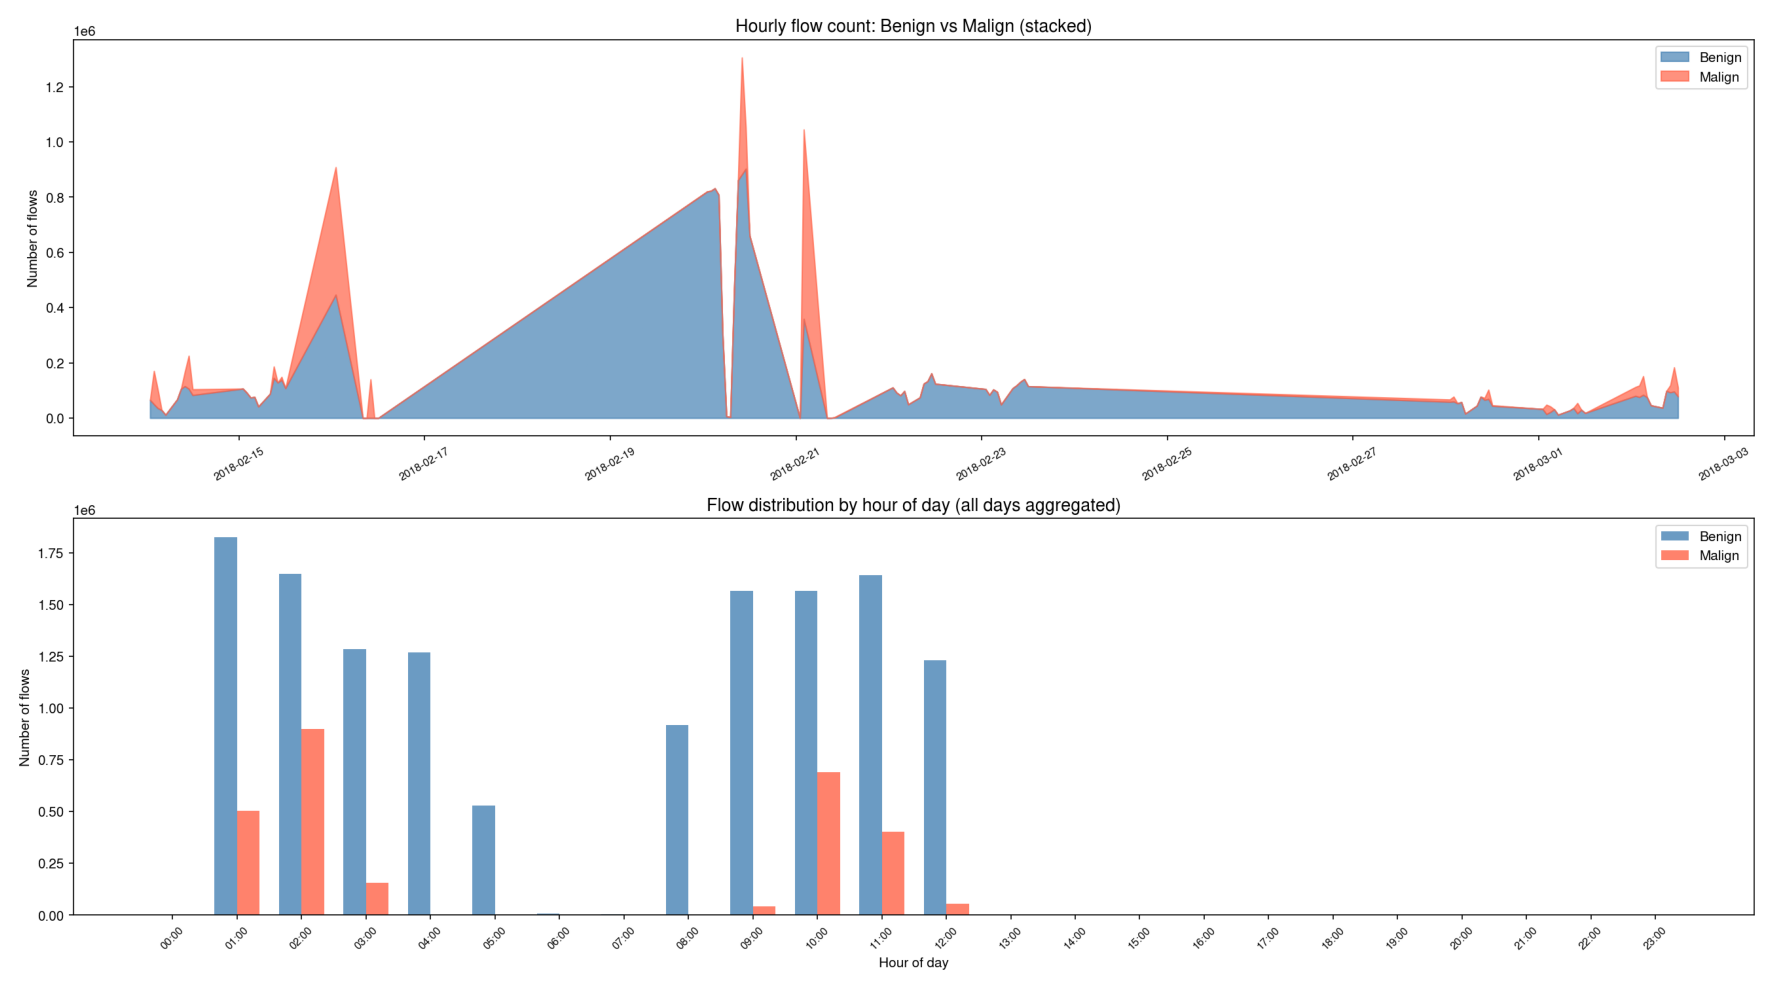

(loaded from cache: images/temporal_distribution_label_generic.png)


In [16]:
if not os.path.exists(img_path_temporal):
    # Aggrego per finestre di 1 ora
    hourly = (
        ts_df
        .groupBy(window('Timestamp', '1 hour'), 'Label_generic')
        .count()
        .withColumn('time', col('window.start'))
        .orderBy('time')
        .toPandas()
    )

    fig, axes = plt.subplots(2, 1, figsize=(18, 10))

    # --- Plot 1: stacked area chart ---
    benign_h = hourly[hourly['Label_generic'] == BENIGN_LABEL].set_index('time')['count']
    malign_h = hourly[hourly['Label_generic'] == MALIGN_LABEL].set_index('time')['count']
    all_times = sorted(set(benign_h.index) | set(malign_h.index))
    benign_h = benign_h.reindex(all_times, fill_value=0)
    malign_h = malign_h.reindex(all_times, fill_value=0)

    axes[0].fill_between(all_times, benign_h.values, label='Benign', alpha=0.7, color='steelblue')
    axes[0].fill_between(all_times, benign_h.values, benign_h.values + malign_h.values, label='Malign', alpha=0.7, color='tomato')
    axes[0].set_title('Hourly flow count: Benign vs Malign (stacked)', fontsize=13)
    axes[0].set_ylabel('Number of flows')
    axes[0].legend(loc='upper right')
    axes[0].tick_params(axis='x', rotation=30, labelsize=8)

    # --- Plot 2: distribuzione per ora del giorno ---
    hour_of_day = (
        ts_df
        .withColumn('hour_of_day', hour('Timestamp'))
        .groupBy('hour_of_day', 'Label_generic')
        .count()
        .orderBy('hour_of_day')
        .toPandas()
    )

    benign_hod = hour_of_day[hour_of_day['Label_generic'] == BENIGN_LABEL].set_index('hour_of_day')['count'].reindex(range(24), fill_value=0)
    malign_hod = hour_of_day[hour_of_day['Label_generic'] == MALIGN_LABEL].set_index('hour_of_day')['count'].reindex(range(24), fill_value=0)

    x = np.arange(24)
    w = 0.35
    axes[1].bar(x - w/2, benign_hod.values, w, label='Benign', color='steelblue', alpha=0.8)
    axes[1].bar(x + w/2, malign_hod.values, w, label='Malign', color='tomato', alpha=0.8)
    axes[1].set_title('Flow distribution by hour of day (all days aggregated)', fontsize=13)
    axes[1].set_xlabel('Hour of day')
    axes[1].set_ylabel('Number of flows')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'{h:02d}:00' for h in range(24)], fontsize=8, rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(img_path_temporal, dpi=150, bbox_inches='tight')
    plt.show()
else:
    img = plt.imread(img_path_temporal)
    plt.figure(figsize=(18, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"(loaded from cache: {img_path_temporal})")

Since the graph shows that attacks are concentrated in certain time slots, then the Timestamp is indeed informative for classification.
Injecting noise into the Timestamp (or into the IAT (Inter-Arrival Time) features) could disrupt this temporal pattern, causing significant degradation.
You'll have a third axis of analysis: not only which features are corrupted and how much noise you add, but also in which time slot the noise has the greatest impact.

### 1.4. Missing data?

In [17]:
if not MISSING_DATA_ALREADY_REMOVED:
    # Conta le features con valori mancanti (null)
    null_counts = uni_feature.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in uni_feature.columns
    ]).toPandas()

    null_count_features = int((null_counts > 0).sum(axis=1).iloc[0])

print(f"in totale ci sono {null_count_features}/{n_features0} features con valori mancanti")

in totale ci sono 1/79 features con valori mancanti


it seemed like only one fefature has missing values, let's investrigate further:

In [18]:
def conteggio_valori_nulli_per_colonna(df):
    # Conta i null per ogni colonna
    null_counts = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).collect()[0]

    # Filtra solo le colonne con almeno un valore nullo
    colonne_con_null = [(c, null_counts[c]) for c in df.columns if null_counts[c] > 0]
    # Ordina per numero di null decrescente
    colonne_con_null_sorted = sorted(colonne_con_null, key=lambda x: x[1], reverse=True)
    print(f"Ci sono {len(colonne_con_null_sorted)} colonne con valori nulli su {len(df.columns)} totali.")

    for colonna, num_valori_nulli in colonne_con_null_sorted:
        print(f"Colonna '{colonna}': {num_valori_nulli} valori nulli")
        print(f"Percentuale di valori nulli: {num_valori_nulli / df.count() * 100:.2f}%")
        print()
        if num_valori_nulli > 0:
            print("Record con valori nulli:")
            records_con_null = df.filter(col(colonna).isNull())
            records_con_null.show(truncate=False)

By running above function it was shown that only 0.37% of all rows had some missing data inside a single feature. To avoid starting with missing data we decided to drop the rows containing missing data (most of them were also negative cases so it has very few impact on final outcome)

In [19]:
if null_count_features > 0:
    conteggio_valori_nulli_per_colonna(dataset)

Ci sono 1 colonne con valori nulli su 81 totali.
Colonna 'Flow Byts/s': 59721 valori nulli
Percentuale di valori nulli: 0.37%

Record con valori nulli:
+--------+--------+-------------------+-------------+------------+------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+-----------+-----------+-------------+------------+------------+------------+-----------+------------+-----------+-----------+-----------+-----------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+--------------+--------------+----------+----------+-----------+-----------+------------+-----------+-----------+------------+------------+------------+------------+------------+------------+--------------+------------+-------------+------------+----------------+----------------+--------------+--------------+----------------+--------------+----------

since those rows represent not even 1% of total dataset it's decided to delete them

In [20]:
if null_count_features > 0:
    # Drop delle righe con valori nulli
    dataset = dataset.na.drop()
    #conteggio_valori_nulli_per_colonna(dataset)

### 1.5. Infinite values (inf)?

Similarly to missing data, infinite values (`inf` / `-inf`) can silently corrupt statistical computations (mean, std, correlation) and break many ML models. Let's check if any feature contains them.

In [21]:
# Casto tutte le colonne (tranne Timestamp) a double per garantire che i check su inf funzionino
exclude_cols = ['Timestamp']
cast_cols = [c for c in uni_feature.columns if c not in exclude_cols]

for c in cast_cols:
    uni_feature = uni_feature.withColumn(c, col(c).cast('double'))
    dataset = dataset.withColumn(c, col(c).cast('double'))

# Ora identifico le colonne numeriche (dovrebbero essere tutte double)
numeric_feature_cols = [
    c for c, dtype in uni_feature.dtypes
    if dtype in ('int', 'bigint', 'float', 'double')
]
print(f"Colonne numeriche dopo cast: {len(numeric_feature_cols)} / {len(uni_feature.columns)}")

# Conta le features che contengono almeno un valore infinito (+inf o -inf)
if not INF_DATA_ALREADY_REMOVED:
    inf_counts = uni_feature.select([
        count(when(
            col(c).isin(float('inf'), float('-inf')), c
        )).alias(c)
        for c in numeric_feature_cols
    ]).toPandas()

    inf_count_features = int((inf_counts > 0).sum(axis=1).iloc[0])
else:
    inf_count_features = 0

print(f"In totale ci sono {inf_count_features}/{n_features0} features con valori infiniti (inf / -inf)")

Colonne numeriche dopo cast: 78 / 79
In totale ci sono 2/79 features con valori infiniti (inf / -inf)


Let's investigate which features contain infinite values, how many, and what percentage of the dataset they represent:

Since infinite values can corrupt aggregations and model training, we replace them with `null` and then drop the affected rows (same strategy used for missing data in section 1.4). If the percentage is very small this has negligible impact on the dataset.

In [23]:
if not INF_DATA_ALREADY_REMOVED:
    count_before = dataset.count()

    # Sostituisci +inf e -inf con null in tutte le colonne numeriche
    for c in numeric_feature_cols:
        dataset = dataset.withColumn(
            c,
            when(col(c).isin(float('inf'), float('-inf')), F.lit(None)).otherwise(col(c))
        )

    # Elimina le righe che ora contengono null (ex-inf)
    dataset = dataset.na.drop()

    count_after = dataset.count()
    removed = count_before - count_after

    print(f"Righe rimosse contenenti valori infiniti: {removed:,}")
    print(f"Dataset: {count_before:,} → {count_after:,} righe")
    print(f"Percentuale rimossa: {removed / count_before * 100:.4f}%")

else:
    print("Nessun valore infinito da rimuovere ✓")

Righe rimosse contenenti valori infiniti: 36,098
Dataset: 16,173,281 → 16,137,183 righe
Percentuale rimossa: 0.2232%


## 2. Feature relevance study

### 2.1. Bivariate correlation analysis - checking for redundant features

If two features are not independent of each other, they have a high absolute correlation and the information they provide for our LM is essentially the same.

Correlated features generally do not improve models, so one can be eliminated as it is redundant. With the following code we can select highly correlated features (85% correlated with another feature):

Numeric columns used for correlation: 78


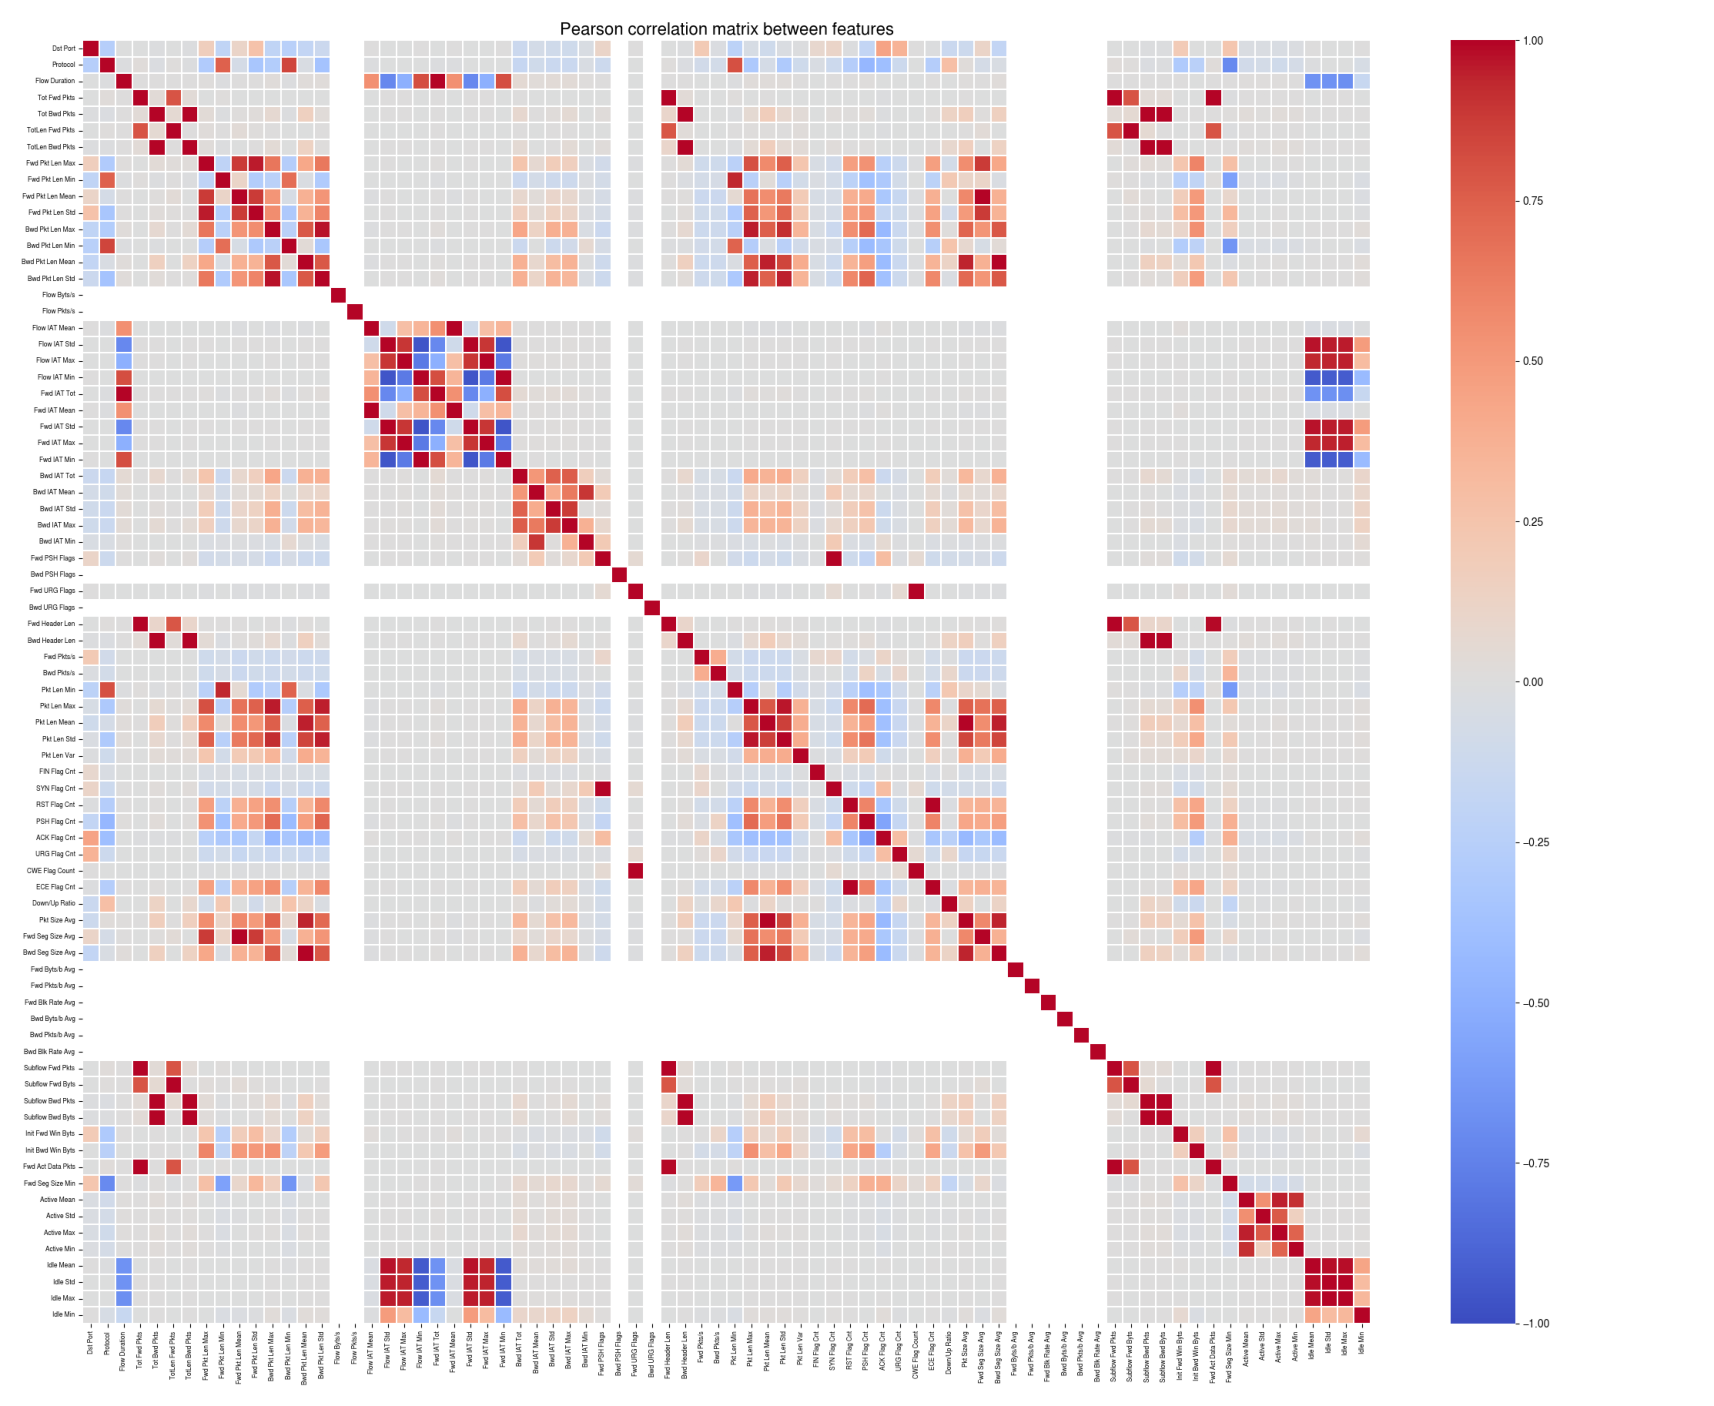

In [24]:
# Tutte le colonne di uni_feature sono stringhe: castiamo a double quelle che non sono Label/target
# Escludo colonne non numeriche come "Timestamp"
exclude_cols = ['Timestamp']
cast_cols = [c for c in uni_feature.columns if c not in exclude_cols]

uni_feature_numeric = uni_feature
for c in cast_cols:
    uni_feature_numeric = uni_feature_numeric.withColumn(c, col(c).cast('double'))

# Prendo solo le colonne numeriche (ora dovrebbero essere tutte double)
numeric_cols = [
    c for c, dtype in uni_feature_numeric.dtypes
    if dtype in ('int', 'bigint', 'float', 'double')
]
print(f"Numeric columns used for correlation: {len(numeric_cols)}")

# Assemblo tutte le feature numeriche in un unico vettore
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features", handleInvalid="skip")
df_vector = assembler.transform(uni_feature_numeric.na.drop(subset=numeric_cols)).select("features")

if not os.path.exists(f'{PATH_IMG}/feature-correlation-heatmap.png'):
    # Calcolo la matrice di correlazione di Pearson tramite Spark
    corr_matrix = Correlation.corr(df_vector, "features", method="pearson").head()[0]
    corr_np = corr_matrix.toArray()
    
    # Converto in DataFrame pandas per visualizzazione
    corr_pd = pd.DataFrame(corr_np, index=numeric_cols, columns=numeric_cols)

    # --- Heatmap completa ---
    plt.figure(figsize=(22, 18))
    sns.heatmap(
        corr_pd,
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.1,
        xticklabels=True,
        yticklabels=True,
    )
    plt.title('Pearson correlation matrix between features', fontsize=16)
    plt.xticks(fontsize=6, rotation=90)
    plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.savefig(f'{PATH_IMG}/feature-correlation-heatmap.png')
    plt.show()
else:
    #show existing heatmap
    img = plt.imread(f'{PATH_IMG}/feature-correlation-heatmap.png')
    plt.figure(figsize=(22, 18))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#### 2.1.1. Feature with no variance at all:

In [25]:
# 1. Feature con varianza zero (costanti)
zero_var_features = []

if not os.path.exists(f'{PATH}/features_to_drop_zero_variance.csv'):
    for c in numeric_cols:
        stats = uni_feature_numeric.select(F.stddev(col(c)).alias('std')).collect()[0]
        if stats['std'] is None or stats['std'] == 0.0:
            zero_var_features.append(c)
    
    #save features to drop to csv
    with open(f'{PATH}/features_to_drop_zero_variance.csv', 'w') as f:
        for feature in sorted(zero_var_features):
            f.write(f"{feature}\n")
else:
    with open(f'{PATH}/features_to_drop_zero_variance.csv', 'r') as f:
        zero_var_features = [line.strip() for line in f if line.strip()]

print(f"Feature with zero variance (Constants): {len(zero_var_features)}")
for f in zero_var_features:
    sample_val = uni_feature_numeric.select(col(f)).filter(col(f).isNotNull()).first()
    print(f"  - {f}  (constant value: {sample_val[0] if sample_val else 'NULL'})")

Feature with zero variance (Constants): 8
  - Bwd Blk Rate Avg  (constant value: 0.0)
  - Bwd Byts/b Avg  (constant value: 0.0)
  - Bwd PSH Flags  (constant value: 0.0)
  - Bwd Pkts/b Avg  (constant value: 0.0)
  - Bwd URG Flags  (constant value: 0.0)
  - Fwd Blk Rate Avg  (constant value: 0.0)
  - Fwd Byts/b Avg  (constant value: 0.0)
  - Fwd Pkts/b Avg  (constant value: 0.0)


#### 2.1.2. Feature with high correlation:

In [26]:
# --- Identifico coppie altamente correlate (|r| >= 0.85) ---
threshold = 0.85
high_corr_pairs = []

if not os.path.exists(f'{PATH}/high_correlation_pairs.csv'):
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            r = corr_np[i][j]
            if abs(r) >= threshold:
                high_corr_pairs.append((numeric_cols[i], numeric_cols[j], round(r, 4)))

    high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
    high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False).reset_index(drop=True)
    #save to csv
    high_corr_df.to_csv(f'{PATH}/high_correlation_pairs.csv', index=False)
else:
    high_corr_df = pd.read_csv(f'{PATH}/high_correlation_pairs.csv')

print(f"\nPairs of features with |correlation| >= {threshold}: {len(high_corr_df)}")
display(high_corr_df)


Pairs of features with |correlation| >= 0.85: 80


,Feature_1,Feature_2,Correlation
0,Flow Duration,Fwd IAT Tot,1.0000
1,TotLen Bwd Pkts,Subflow Bwd Byts,1.0000
2,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.0000
3,Flow IAT Max,Fwd IAT Max,1.0000
4,Flow IAT Min,Fwd IAT Min,1.0000
...,...,...,...
75,Fwd Pkt Len Max,Fwd Seg Size Avg,0.8773
76,Fwd Pkt Len Max,Fwd Pkt Len Mean,0.8773
77,Pkt Len Mean,Pkt Len Std,0.8656
78,Bwd Pkt Len Mean,Pkt Len Std,0.8512


In [28]:
# List of candidate features for removal (one for each redundant pair)
features_to_drop = set()

if not os.path.exists(f'{PATH}/features_to_drop_high_correlation.csv'):
    for _, row in high_corr_df.iterrows():
        # Remove the second feature of the pair (arbitrary choice)
        features_to_drop.add(row['Feature_2'])
        
    #save features to drop to csv
    with open(f'{PATH}/features_to_drop_high_correlation.csv', 'w') as f:
        for feature in sorted(features_to_drop):
            f.write(f"{feature}\n")
else:
    features_to_drop_df = pd.read_csv(f'{PATH}/features_to_drop_high_correlation.csv', header=None)
    features_to_drop = set(features_to_drop_df[0].tolist())  

print(f"\nCandidate features for removal ({len(features_to_drop)}):")
for f in sorted(features_to_drop):
    print(f"  - {f}")


Candidate features for removal (35):
  - Active Max
  - Active Min
  - Bwd Header Len
  - Bwd IAT Max
  - Bwd IAT Min
  - Bwd Pkt Len Std
  - Bwd Seg Size Avg
  - CWE Flag Count
  - ECE Flag Cnt
  - Flow IAT Max
  - Flow IAT Min
  - Fwd Act Data Pkts
  - Fwd Header Len
  - Fwd IAT Max
  - Fwd IAT Mean
  - Fwd IAT Min
  - Fwd IAT Std
  - Fwd IAT Tot
  - Fwd Pkt Len Mean
  - Fwd Pkt Len Std
  - Fwd Seg Size Avg
  - Idle Max
  - Idle Mean
  - Idle Std
  - Pkt Len Max
  - Pkt Len Mean
  - Pkt Len Min
  - Pkt Len Std
  - Pkt Size Avg
  - SYN Flag Cnt
  - Subflow Bwd Byts
  - Subflow Bwd Pkts
  - Subflow Fwd Byts
  - Subflow Fwd Pkts
  - TotLen Bwd Pkts


### 2.2. Dropping those featurese

In [29]:
cols_to_drop = list(features_to_drop) + zero_var_features
dataset = dataset.drop(*cols_to_drop)
numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
print(f"\nAfter dropping zero-variance and highly correlated features, {len(numeric_cols)} numeric features remain.")


After dropping zero-variance and highly correlated features, 35 numeric features remain.


In [32]:
if not SKIP_INTERMEDIATE_SAVE:
    dataset.write.parquet(f'{PATH}/all_elaborated.parquet', mode='overwrite')

After dropping those features we continue feature relevance analysis

### 2.4. Categorical features?

Usually this is not something we should worry about in a section dedicated to find most relevant features, but this information is pretty necessary for pucktrick library to process data (and now it's the perfect time to do is since we just dropped a lot of features) 

Categorical analysis saved to DATASETS/categorical_features.csv

BINARY FEATURES (exactly 2 distinct values)
Found 8 binary features out of 36 total columns



,feature,n_distinct_values,is_binary,is_categorical
0,label_generic,2,True,False
1,FIN Flag Cnt,2,True,False
2,RST Flag Cnt,2,True,False
3,PSH Flag Cnt,2,True,False
4,ACK Flag Cnt,2,True,False
5,URG Flag Cnt,2,True,False
6,Fwd PSH Flags,2,True,False
7,Fwd URG Flags,2,True,False



CATEGORICAL FEATURES (3 ≤ distinct values ≤ 200)
Found 2 categorical features out of 36 total columns



,feature,n_distinct_values,is_binary,is_categorical
8,Protocol,3,False,True
9,Fwd Seg Size Min,11,False,True


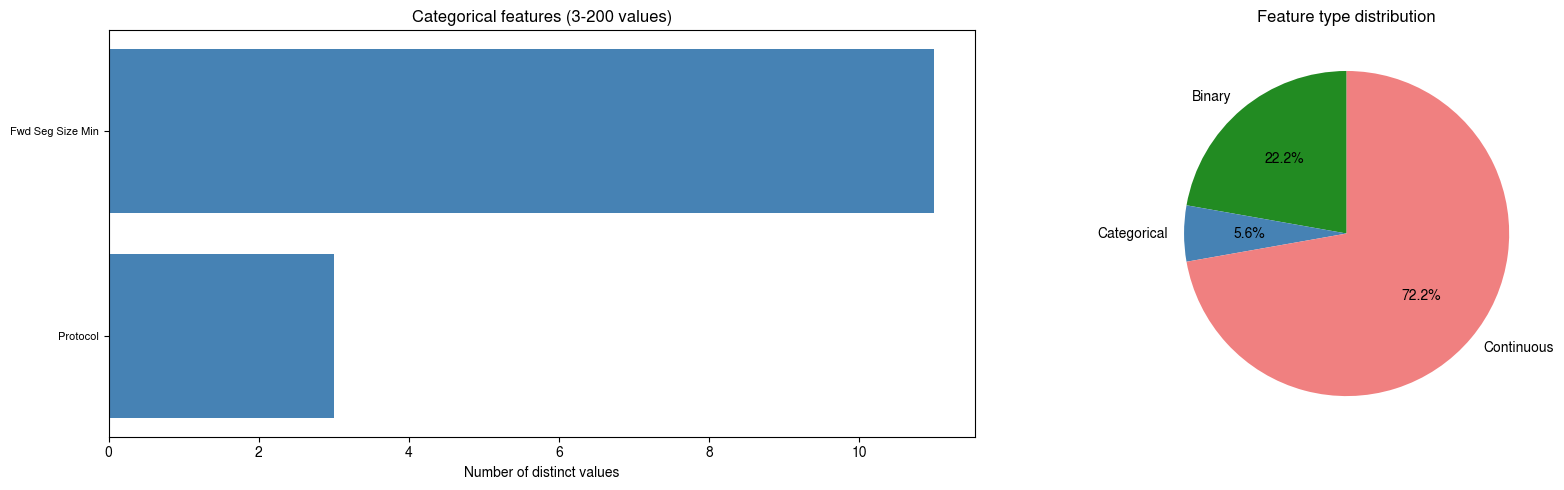

In [ ]:
# ── Identificazione delle feature categoriche e binarie ──
CATEGORICAL_THRESHOLD_MIN = 3
CATEGORICAL_THRESHOLD_MAX = 200
categorical_path = f'{PATH}/categorical_features.csv'

if not os.path.exists(categorical_path):
    # Calcolo il numero di valori distinti per ogni colonna (escludo i target)
    all_cols = [c for c in dataset.columns if c not in ['Label', 'Label_generic', 'Timestamp']]
    
    for c in numeric_cols:
        dataset = dataset.withColumn(c, col(c).cast("double"))
    
    categorical_info = []
    for c in all_cols:
        n_distinct = dataset.select(c).distinct().count()
        categorical_info.append({
            'feature': c,
            'n_distinct_values': n_distinct,
            'is_binary': n_distinct == 2,
            'is_categorical': CATEGORICAL_THRESHOLD_MIN <= n_distinct <= CATEGORICAL_THRESHOLD_MAX
        })
    
    categorical_df = pd.DataFrame(categorical_info)
    categorical_df = categorical_df.sort_values('n_distinct_values', ascending=True).reset_index(drop=True)
    
    # Salvo su CSV
    categorical_df.to_csv(categorical_path, index=False)
    print(f"Categorical analysis saved to {categorical_path}")
else:
    categorical_df = pd.read_csv(categorical_path)
    print(f"Categorical analysis loaded from cache ({categorical_path})")

# ── Filtra feature binarie e categoriche ──
binary_features = categorical_df[categorical_df['is_binary'] == True].copy()
categorical_features = categorical_df[categorical_df['is_categorical'] == True].copy()

print(f"\n{'='*70}")
print(f"BINARY FEATURES (exactly 2 distinct values)")
print(f"{'='*70}")
print(f"Found {len(binary_features)} binary features out of {len(categorical_df)} total columns\n")
display(binary_features)

print(f"\n{'='*70}")
print(f"CATEGORICAL FEATURES ({CATEGORICAL_THRESHOLD_MIN} ≤ distinct values ≤ {CATEGORICAL_THRESHOLD_MAX})")
print(f"{'='*70}")
print(f"Found {len(categorical_features)} categorical features out of {len(categorical_df)} total columns\n")
display(categorical_features)

# ── Visualizzazione: distribuzione dei tipi di feature ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Barplot per feature categoriche (3-200 valori)
if len(categorical_features) > 0:
    axes[0].barh(categorical_features['feature'], categorical_features['n_distinct_values'], color='steelblue')
    axes[0].set_xlabel('Number of distinct values')
    axes[0].set_title(f'Categorical features ({CATEGORICAL_THRESHOLD_MIN}-{CATEGORICAL_THRESHOLD_MAX} values)')
    axes[0].tick_params(axis='y', labelsize=8)
else:
    axes[0].text(0.5, 0.5, 'No categorical features', ha='center', va='center')
    axes[0].set_title('Categorical features')

# Pie chart: binarie vs categoriche vs continue
continuous_count = len(categorical_df) - len(binary_features) - len(categorical_features)
sizes = [len(binary_features), len(categorical_features), continuous_count]
labels_pie = ['Binary', 'Categorical', 'Continuous']
colors_pie = ['forestgreen', 'steelblue', 'lightcoral']

# Rimuovi categorie vuote dal pie chart
non_zero = [(s, l, c) for s, l, c in zip(sizes, labels_pie, colors_pie) if s > 0]
if non_zero:
    sizes_nz, labels_nz, colors_nz = zip(*non_zero)
    axes[1].pie(sizes_nz, labels=labels_nz, autopct='%1.1f%%', colors=colors_nz, startangle=90)
axes[1].set_title('Feature type distribution')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/categorical_binary_features_analysis.png', dpi=150)
plt.show()

### 2.3. Feature fragility

Understanding the distribution of each feature is crucial to your design: when injecting noise with pucktrick, you need to know what "normality" is to quantify the deviation. Features with highly skewed distributions or natural outliers will react differently to noise.

In [ ]:
# ── Calcolo statistiche descrittive per tutte le feature numeriche ──
# Escludo colonne non numeriche e target
exclude = ['Timestamp', 'Label', 'label_generic', 'Protocol']
# All feature columns are stored as string; select those that should be numeric and cast them
num_cols = [c for c in dataset.columns if c not in exclude]

# Cast selected columns to double so that aggregate functions work
dataset = dataset.select(
    *[_col(c).cast('double').alias(c) if c in num_cols else _col(c) for c in dataset.columns]
)

stats_path = f'{PATH}/feature_distribution_stats.csv'

if not os.path.exists(stats_path):
    # Calcolo mean, stddev, min, max, skewness, kurtosis via Spark
    agg_exprs = []
    for c in num_cols:
        agg_exprs.extend([
            F.mean(col(c)).alias(f'{c}__mean'),
            F.stddev(col(c)).alias(f'{c}__std'),
            F.min(col(c)).alias(f'{c}__min'),
            F.max(col(c)).alias(f'{c}__max'),
            F.skewness(col(c)).alias(f'{c}__skew'),
            F.kurtosis(col(c)).alias(f'{c}__kurt'),
        ])

    raw = dataset.agg(*agg_exprs).collect()[0]

    rows = []
    for c in num_cols:
        rows.append({
            'feature': c,
            'mean':     raw[f'{c}__mean'],
            'std':      raw[f'{c}__std'],
            'min':      raw[f'{c}__min'],
            'max':      raw[f'{c}__max'],
            'skewness': raw[f'{c}__skew'],
            'kurtosis': raw[f'{c}__kurt'],
        })

    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(stats_path, index=False)
    print(f"Stats computed and saved to {stats_path}")
else:
    stats_df = pd.read_csv(stats_path)
    print(f"Stats loaded from cache ({stats_path})")

# ── Tabella riassuntiva ──
print(f"\nDescriptive statistics for {len(stats_df)} numeric features:\n")
display(stats_df.round(4))

# ── Evidenzio feature molto skewed (|skewness| > 2) ──
highly_skewed = stats_df[stats_df['skewness'].abs() > 2].sort_values('skewness', key=abs, ascending=False)
print(f"\n⚠ Highly skewed features (|skewness| > 2): {len(highly_skewed)}/{len(stats_df)}")
if len(highly_skewed) > 0:
    display(highly_skewed[['feature', 'skewness', 'kurtosis', 'min', 'max']].reset_index(drop=True))

Stats computed and saved to DATASETS/feature_distribution_stats.csv

Descriptive statistics for 34 numeric features:



,feature,mean,std,min,max,skewness,kurtosis
0,Dst Port,8.917961e+03,1.869600e+04,0.000000e+00,6.553500e+04,1.9139,1.839500e+00
1,Flow Duration,1.188391e+07,4.954751e+08,-9.190110e+11,1.200000e+08,-1430.5911,2.159345e+06
2,Tot Fwd Pkts,2.366100e+01,1.525642e+03,1.000000e+00,3.096290e+05,88.2947,8.222501e+03
3,Tot Bwd Pkts,6.350100e+00,1.645109e+02,0.000000e+00,1.231180e+05,170.3009,6.150375e+04
4,TotLen Fwd Pkts,9.787339e+02,6.235320e+04,0.000000e+00,1.443918e+08,834.2151,1.798058e+06
5,Fwd Pkt Len Max,2.018772e+02,3.040568e+02,0.000000e+00,6.444000e+04,4.5881,5.352561e+02
6,Fwd Pkt Len Min,1.113820e+01,2.428500e+01,0.000000e+00,1.460000e+03,11.3964,3.961523e+02
7,Bwd Pkt Len Max,3.522270e+02,4.981633e+02,0.000000e+00,6.516000e+04,1.6643,5.521590e+01
8,Bwd Pkt Len Min,2.663490e+01,5.108890e+01,0.000000e+00,1.460000e+03,2.1038,5.749300e+00
9,Bwd Pkt Len Mean,1.137466e+02,1.643600e+02,0.000000e+00,3.387928e+04,4.3162,2.043537e+02



⚠ Highly skewed features (|skewness| > 2): 28/34


,feature,skewness,kurtosis,min,max
0,Flow IAT Mean,-3368.194427,1.199692e+07,-8.282200e+11,1.200000e+08
1,Idle Min,3329.391617,1.239270e+07,0.000000e+00,2.399340e+11
2,Pkt Len Var,1858.706307,4.272320e+06,0.000000e+00,5.190000e+08
3,Flow Duration,-1430.591112,2.159345e+06,-9.190110e+11,1.200000e+08
4,Flow IAT Std,1204.902504,1.479867e+06,0.000000e+00,4.743545e+11
5,TotLen Fwd Pkts,834.215109,1.798058e+06,0.000000e+00,1.443918e+08
6,Tot Bwd Pkts,170.300922,6.150375e+04,0.000000e+00,1.231180e+05
7,Down/Up Ratio,128.376542,2.736980e+04,0.000000e+00,3.110000e+02
8,Tot Fwd Pkts,88.294691,8.222501e+03,1.000000e+00,3.096290e+05
9,Flow Byts/s,80.550848,1.984987e+04,0.000000e+00,1.806643e+09


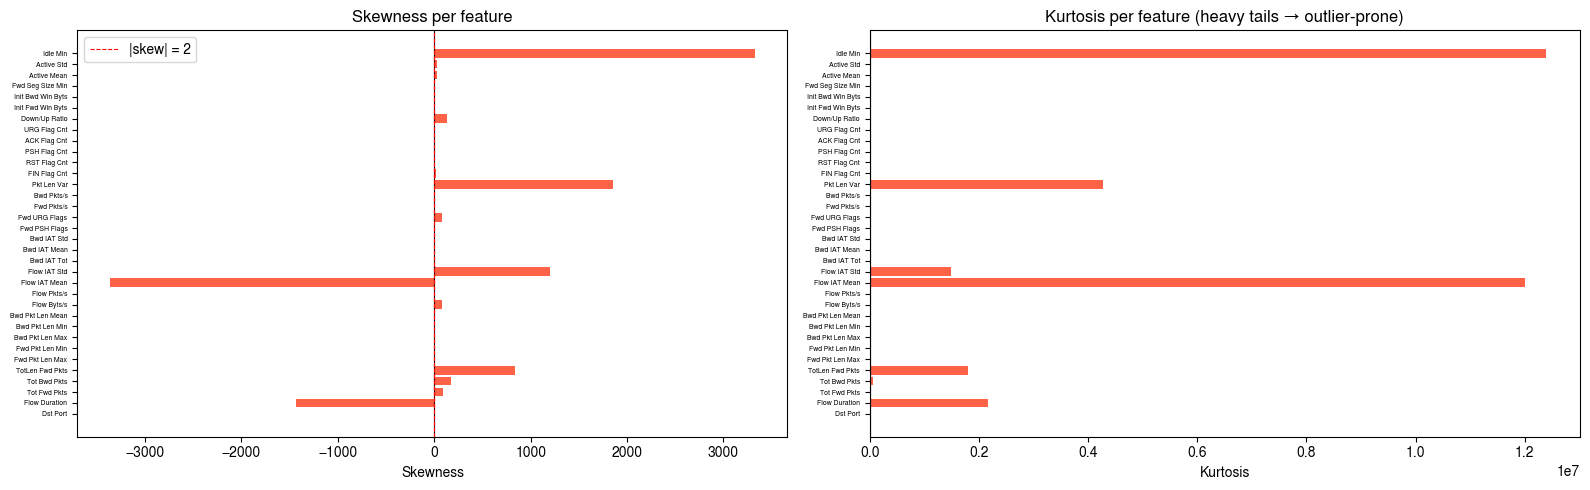

In [ ]:
# ── Visualizzazione: distribuzione di skewness e kurtosis ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(stats_df['feature'], stats_df['skewness'], color=np.where(stats_df['skewness'].abs() > 2, 'tomato', 'steelblue'))
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].axvline(x=2, color='red', linewidth=0.8, linestyle='--', label='|skew| = 2')
axes[0].axvline(x=-2, color='red', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Skewness')
axes[0].set_title('Skewness per feature')
axes[0].tick_params(axis='y', labelsize=5)
axes[0].legend()

axes[1].barh(stats_df['feature'], stats_df['kurtosis'], color=np.where(stats_df['kurtosis'].abs() > 7, 'tomato', 'steelblue'))
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Kurtosis')
axes[1].set_title('Kurtosis per feature (heavy tails → outlier-prone)')
axes[1].tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/feature-skew-kurtosis.png', dpi=150)
plt.show()

Skewness (Asimmetria): La skewness misura quanto una distribuzione è asimmetrica rispetto alla media.
- Skewness = 0 → distribuzione simmetrica (es. normale ideale)
- Skewness > 0 → coda più lunga a destra (asimmetria positiva)
- Skewness < 0 → coda più lunga a sinistra (asimmetria negativa)

Cosa notare nell' esperimento:
Feature con alta skewness positiva (la maggior parte delle tue): il rumore gaussiano centrato in 0 sposterà molti campioni verso valori negativi che non esistono nel dominio reale → il modello vedrà pattern mai osservati in training
Feature con alta skewness negativa (es. Flow Duration, skew = −1432): quasi tutti i valori sono concentrati al massimo; il rumore tenderà a abbassarli — potrebbe far sembrare flussi lunghi come flussi corti (Benign → Malign?)

Kurtosis: indice di quatno sono frequenti outliers:
- Kurtosis ≈ 3 → simile alla distribuzione normale (mesocurtica)
- Kurtosis > 3 → code pesanti, più outlier (leptocurtica)
- Kurtosis < 3 → code leggere, meno outlier (platicurtica)

La kurtosis ti dice quanto la feature è dominata dagli outlier.

Le feature con kurtosis altissima sono quelle dove anche poco rumore può avere effetto devastante, perché il modello deep ha probabilmente imparato a distinguere Benign da Malign proprio su quei picchi rari.

In [ ]:
# ── Classificazione feature per fragilità attesa al rumore ──
stats_df['abs_skewness'] = stats_df['skewness'].abs()
stats_df['abs_kurtosis'] = stats_df['kurtosis'].abs()

# Soglie
skew_thresh = 2
kurt_thresh = 10

def classify_fragility(row):
    high_skew = row['abs_skewness'] > skew_thresh
    high_kurt = row['abs_kurtosis'] > kurt_thresh
    if high_skew and high_kurt:
        return '🔴 High fragility'
    elif high_skew or high_kurt:
        return '🟡 Medium fragility'
    else:
        return '🟢 Low fragility (robust)'

stats_df['noise_fragility'] = stats_df.apply(classify_fragility, axis=1)

# Riepilogo
print("Feature fragility to noise injection:\n")
for level in ['🔴 High fragility', '🟡 Medium fragility', '🟢 Low fragility (robust)']:
    subset = stats_df[stats_df['noise_fragility'] == level]
    print(f"{level}: {len(subset)} features")
    for _, r in subset.iterrows():
        print(f"    {r['feature']:30s}  skew={r['skewness']:>12.2f}  kurt={r['kurtosis']:>12.2f}")
    print()

Feature fragility to noise injection:

🔴 High fragility: 25 features
    Flow Duration                   skew=    -1430.59  kurt=  2159344.76
    Tot Fwd Pkts                    skew=       88.29  kurt=     8222.50
    Tot Bwd Pkts                    skew=      170.30  kurt=    61503.75
    TotLen Fwd Pkts                 skew=      834.22  kurt=  1798057.56
    Fwd Pkt Len Max                 skew=        4.59  kurt=      535.26
    Fwd Pkt Len Min                 skew=       11.40  kurt=      396.15
    Bwd Pkt Len Mean                skew=        4.32  kurt=      204.35
    Flow Byts/s                     skew=       80.55  kurt=    19849.87
    Flow Pkts/s                     skew=        6.80  kurt=       50.04
    Flow IAT Mean                   skew=    -3368.19  kurt= 11996916.81
    Flow IAT Std                    skew=     1204.90  kurt=  1479866.83
    Bwd IAT Tot                     skew=        3.61  kurt=       11.56
    Bwd IAT Mean                    skew=       12.32  

| | **Bassa Kurtosis** | **Alta Kurtosis** |
|---|---|---|
| **Bassa Skewness** | ✅ **Robuste** — rumore ha effetto graduale e prevedibile | ⚠️ Outlier importanti ma distribuzione bilanciata — rumore li può mascherare |
| **Alta Skewness** | ⚠️ Rumore crea valori fuori dominio ma pochi outlier critici | 🔴 **Fragili** — rumore crea valori impossibili E distrugge outlier discriminanti |

Le feature nel quadrante 🔴 (alta skewness + alta kurtosis) sono quelle dove ti aspetti:
1. **Massima degradazione** della predizione con poco rumore
2. **Massimo effetto di robustezza** se usate per il training con rumore (data augmentation)

### 2.4. Correlation to target

In [ ]:
corr_target_path = f'{PATH}/feature_target_correlation.csv'

In [ ]:
# ── Correlation of features with Label_generic (binary) and Label (multi-class) ──
if not os.path.exists(corr_target_path):
    # --- 1. Point-biserial correlation with Label_generic (binary 0/1) ---
    # Pearson correlation with a binary variable = point-biserial correlation
    corr_generic = []
    dataset = dataset.withColumn("label_generic", col("label_generic").cast("double"))
    
    # Cast all numeric_cols to double (some might be stored as string)
    # dataset = spark.read.parquet(f'{PATH}/all_elaborated.parquet')
    for c in numeric_cols:
        dataset = dataset.withColumn(c, col(c).cast("double"))
    
    for c in numeric_cols:
        r = dataset.stat.corr(c, 'label_generic')
        corr_generic.append({'feature': c, 'corr_label_generic': r})

    corr_generic_df = pd.DataFrame(corr_generic)

    # --- 2. ANOVA F-statistic with Label (multi-class) ---
    # F-stat measures how much each feature varies between attack classes
    # Higher F → feature discriminates better among attack types
    from pyspark.sql.window import Window

    # Compute grand mean and per-group mean for each feature
    labels = [row['Label'] for row in dataset.select('Label').distinct().collect()]
    n_total = dataset.count()
    k = len(labels)

    anova_results = []
    for c in numeric_cols:
        # Grand mean
        grand_mean = dataset.agg(F.mean(col(c))).collect()[0][0]
        if grand_mean is None:
            anova_results.append({'feature': c, 'anova_f_label': float('nan')})
            continue

        # Per-group stats
        group_stats = (
            dataset
            .groupBy('Label')
            .agg(
                F.mean(col(c)).alias('group_mean'),
                F.count(col(c)).alias('n_j'),
                F.variance(col(c)).alias('group_var')
            )
            .collect()
        )

        # Between-group sum of squares
        ss_between = sum(
            row['n_j'] * (row['group_mean'] - grand_mean) ** 2
            for row in group_stats
            if row['group_mean'] is not None
        )

        # Within-group sum of squares
        ss_within = sum(
            (row['n_j'] - 1) * row['group_var']
            for row in group_stats
            if row['group_var'] is not None and row['n_j'] > 1
        )

        df_between = k - 1
        df_within = n_total - k

        if ss_within > 0 and df_within > 0 and df_between > 0:
            f_stat = (ss_between / df_between) / (ss_within / df_within)
        else:
            f_stat = float('nan')

        anova_results.append({'feature': c, 'anova_f_label': f_stat})

    anova_df = pd.DataFrame(anova_results)

    # --- Merge everything ---
    corr_target_df = corr_generic_df.merge(anova_df, on='feature')
    corr_target_df['abs_corr_generic'] = corr_target_df['corr_label_generic'].abs()
    corr_target_df.to_csv(corr_target_path, index=False)
    print(f"Target correlation computed and saved to {corr_target_path}")
else:
    corr_target_df = pd.read_csv(corr_target_path)
    print(f"Target correlation loaded from cache ({corr_target_path})")

Target correlation loaded from cache (DATASETS/feature_target_correlation.csv)


To feature we add fragility measure

In [ ]:
# --- Add fragility classification ---
fragility_map = stats_df.set_index('feature')['noise_fragility'].to_dict()
corr_target_df['noise_fragility'] = corr_target_df['feature'].map(fragility_map)

#### 2.4.1. Feature correlation to generic label

In [ ]:
# ── Display: features sorted by correlation to Label_generic ──
print("\n" + "="*90)
print("CORRELATION WITH Label_generic (binary: Benign vs Malign)")
print("  Metric: Pearson / point-biserial correlation")
print("="*90)
by_generic = corr_target_df.sort_values('abs_corr_generic', ascending=False).reset_index(drop=True)
display(by_generic[['feature', 'corr_label_generic', 'abs_corr_generic', 'noise_fragility']].head(30))


CORRELATION WITH Label_generic (binary: Benign vs Malign)
  Metric: Pearson / point-biserial correlation


,feature,corr_label_generic,abs_corr_generic,noise_fragility
0,Fwd Seg Size Min,0.429962,0.429962,🟢 Low fragility (robust)
1,Bwd Pkts/s,0.260093,0.260093,🔴 High fragility
2,Protocol,-0.234482,0.234482,NaN
3,Fwd Pkt Len Mean,-0.229000,0.229000,NaN
4,ACK Flag Cnt,0.223088,0.223088,🟢 Low fragility (robust)
5,Bwd Pkt Len Min,-0.218658,0.218658,🟡 Medium fragility
6,Init Fwd Win Byts,0.218048,0.218048,🟡 Medium fragility
7,Pkt Len Min,-0.202205,0.202205,NaN
8,Fwd Pkt Len Min,-0.190755,0.190755,🔴 High fragility
9,Fwd Pkt Len Max,-0.189037,0.189037,🔴 High fragility


#### 2.4.2. Feature correlation to label

In [ ]:
# ── Display: features sorted by ANOVA F-stat with Label (multi-class) ──
print("\n" + "="*90)
print("DISCRIMINATIVE POWER FOR Label (multi-class: attack subtypes)")
print("  Metric: ANOVA F-statistic (higher = better discrimination)")
print("="*90)
by_anova = corr_target_df.sort_values('anova_f_label', ascending=False).reset_index(drop=True)
display(by_anova[['feature', 'anova_f_label', 'noise_fragility']].head(30))


DISCRIMINATIVE POWER FOR Label (multi-class: attack subtypes)
  Metric: ANOVA F-statistic (higher = better discrimination)


,feature,anova_f_label,noise_fragility
0,Tot Fwd Pkts,2.004973e+06,🔴 High fragility
1,Bwd Pkts/s,1.839066e+06,🔴 High fragility
2,TotLen Fwd Pkts,7.351074e+05,🔴 High fragility
3,Fwd Seg Size Min,6.217833e+05,🟢 Low fragility (robust)
4,Init Fwd Win Byts,3.028720e+05,🟡 Medium fragility
5,ACK Flag Cnt,1.515281e+05,🟢 Low fragility (robust)
6,Fwd Pkts/s,1.387862e+05,🔴 High fragility
7,Bwd IAT Mean,9.873858e+04,🔴 High fragility
8,Fwd Pkt Len Mean,8.700769e+04,NaN
9,URG Flag Cnt,8.183740e+04,🔴 High fragility


#### 2.4.3. Graph both feature correlations

/tmp/ipykernel_6088/2561044843.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Noto Sans Nabataean, Nimbus Roman, Nimbus Sans.
  plt.tight_layout()
/tmp/ipykernel_6088/2561044843.py:52: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Noto Sans Nabataean, Nimbus Roman, Nimbus Sans.
  plt.tight_layout()
/tmp/ipykernel_6088/2561044843.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Noto Sans Nabataean, Nimbus Roman, Nimbus Sans.
  plt.tight_layout()
/tmp/ipykernel_6088/2561044843.py:53: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Noto Sans Nabataean, Nimbus Roman, Nimbus Sans.
  plt.savefig(f'{PATH_IMG}/fragile-features-target-correlation.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_6088/2561044843.py:53: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Noto Sans Nabataean, Nimbus Roman, Nimbus Sans.
  plt.savefig(f'{PATH_IMG}/fragile-features-target

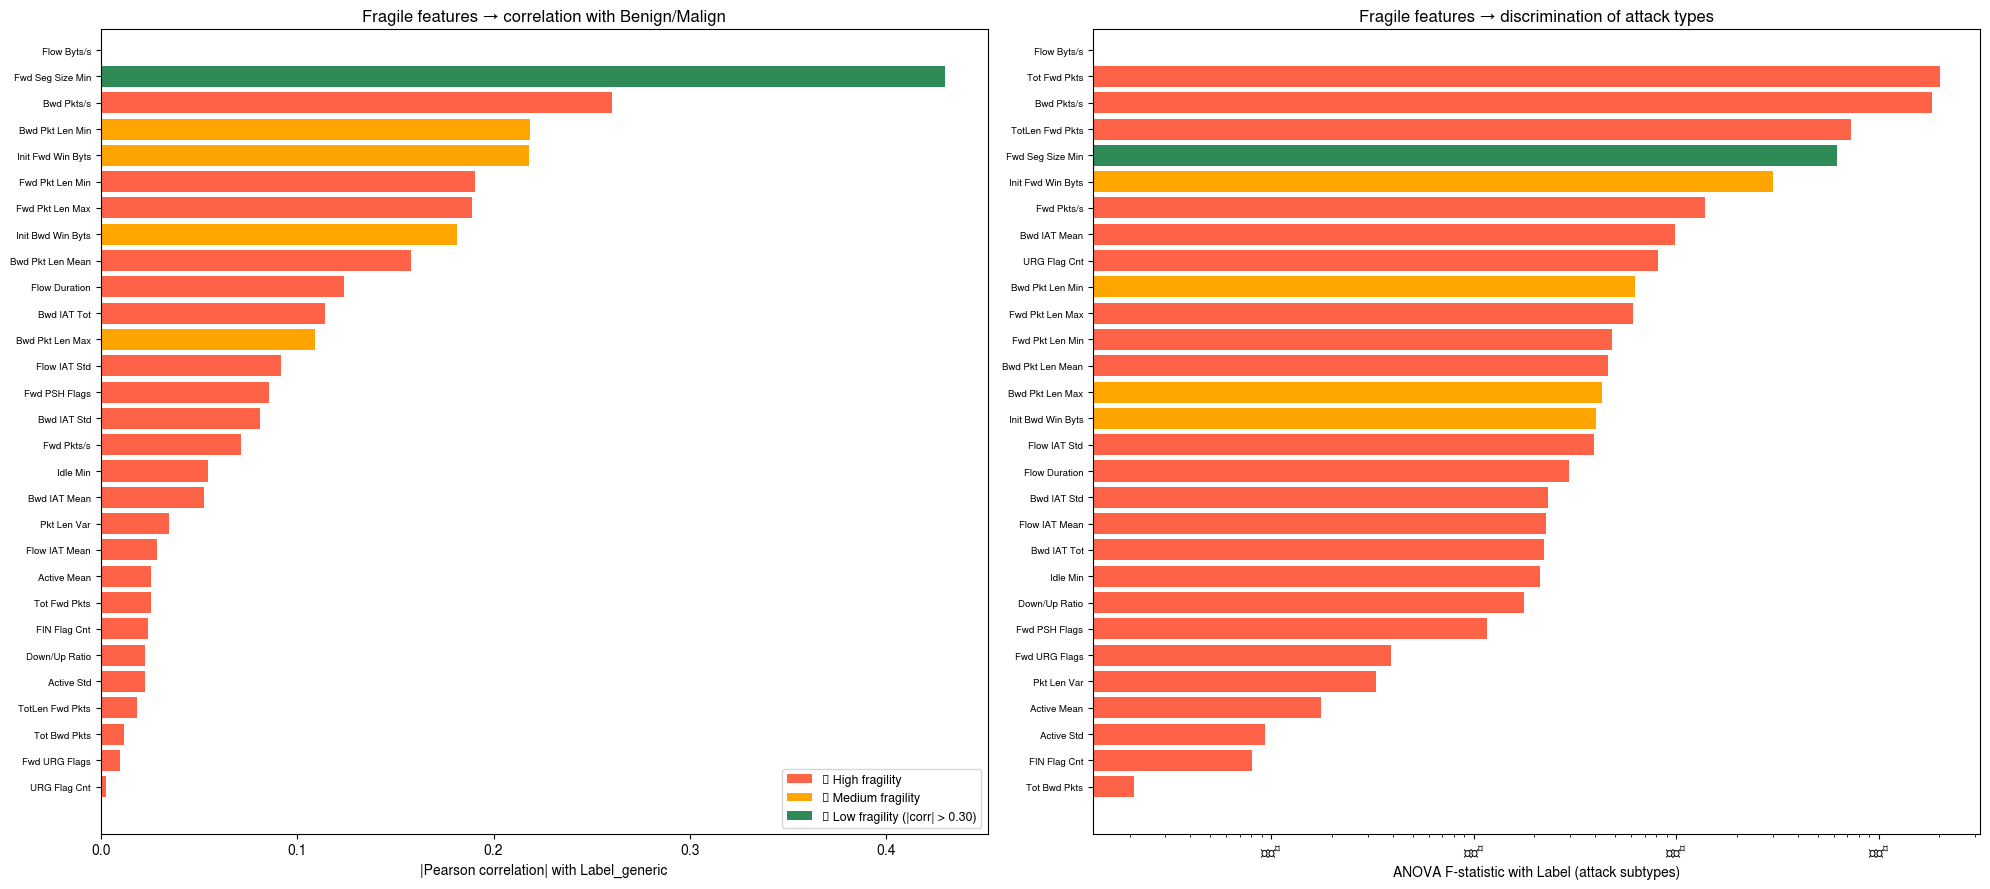

In [ ]:
# ── Visualization: dual bar chart for fragile features ──
# Filter only high/medium fragility features
fragile_features = corr_target_df[
    corr_target_df['noise_fragility'].isin(['🔴 High fragility', '🟡 Medium fragility'])
].copy()

# Add robust features with |correlation| > 0.30
robust_high_corr = corr_target_df[
    (corr_target_df['noise_fragility'] == '🟢 Low fragility (robust)') &
    (corr_target_df['abs_corr_generic'] > 0.30)
].copy()

# Combine both sets
plot_features = pd.concat([fragile_features, robust_high_corr], ignore_index=True)

fragile_by_generic = plot_features.sort_values('abs_corr_generic', ascending=True)
fragile_by_anova   = plot_features.sort_values('anova_f_label', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(plot_features) * 0.3)))

# Color by fragility
color_map = {
    '🔴 High fragility': 'tomato',
    '🟡 Medium fragility': 'orange',
    '🟢 Low fragility (robust)': 'seagreen',
}

# Left: correlation with Label_generic
colors_g = [color_map.get(f, 'steelblue') for f in fragile_by_generic['noise_fragility']]
axes[0].barh(fragile_by_generic['feature'], fragile_by_generic['abs_corr_generic'], color=colors_g)
axes[0].set_xlabel('|Pearson correlation| with Label_generic')
axes[0].set_title('Fragile features → correlation with Benign/Malign', fontsize=12)
axes[0].tick_params(axis='y', labelsize=7)

# Right: ANOVA F-stat with Label
colors_a = [color_map.get(f, 'steelblue') for f in fragile_by_anova['noise_fragility']]
axes[1].barh(fragile_by_anova['feature'], fragile_by_anova['anova_f_label'], color=colors_a)
axes[1].set_xlabel('ANOVA F-statistic with Label (attack subtypes)')
axes[1].set_title('Fragile features → discrimination of attack types', fontsize=12)
axes[1].tick_params(axis='y', labelsize=7)
axes[1].set_xscale('log')  # F-stats vary enormously, log scale helps

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato', label='🔴 High fragility'),
    Patch(facecolor='orange', label='🟡 Medium fragility'),
    Patch(facecolor='seagreen', label='🟢 Low fragility (|corr| > 0.30)'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fragile-features-target-correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Come si può vedere non ci sono molte colonne che hanno altissima correlazione con il target, anzi la correlazione è abbastanza bassa su tutte le colonne (anche quelle più correlate in assoluto raggiongono al massimo 40%) di correlazione con pearson. Questo comunque è un dato aspettato in quanto:
1) non abbiamo accesso al payload dei pacchetti esaminati (per motivi di privacy) che sarebbe la caratteristica numero uno per denominare se un pacchetto è maligno o meno
2) un qualcuno che vuole creare un attacco vuole voolontariamente che sia meno tracciabile possibile, se ci fosse una colonna con alta correlazione con il target sarebbe in indicatore troppo evidente della presenza di un attacco.

In [ ]:
# Build a mapping from feature name to data type using already-defined variables
binary_set = set(binary_features['feature'].tolist())
categorical_set = set(categorical_features['feature'].tolist())

def get_data_type(feat_name):
    if feat_name in binary_set:
        return 'binary'
    elif feat_name in categorical_set:
        return 'categorical'
    else:
        return 'continuous'

# Sort descending (reverse the ascending-sorted DataFrames)
save_generic = fragile_by_generic.iloc[::-1].copy()
save_anova = fragile_by_anova.iloc[::-1].copy()

# Add data_type column
save_generic['data_type'] = save_generic['feature'].apply(get_data_type)
save_anova['data_type'] = save_anova['feature'].apply(get_data_type)

save_generic.to_csv(f'{PATH}/features_high_correlation_label_generic.csv', index=False)
save_anova.to_csv(f'{PATH}/features_high_correlation_label.csv', index=False)

print(f"Saved {len(save_generic)} features to features_high_correlation_label_generic.csv (sorted by |corr| with Label_generic, descending)")
print(f"Saved {len(save_anova)} features to features_high_correlation_label.csv (sorted by ANOVA F-stat with Label, descending)")
print(f"\nData type distribution:")
print(save_generic['data_type'].value_counts().to_string())

Saved 30 features to features_high_correlation_label_generic.csv (sorted by |corr| with Label_generic, descending)
Saved 30 features to features_high_correlation_label.csv (sorted by ANOVA F-stat with Label, descending)

Data type distribution:
data_type
continuous     25
binary          4
categorical     1


In [ ]:
display(save_generic[['feature', 'corr_label_generic', 'abs_corr_generic', 'noise_fragility', 'data_type']])
display(save_anova[['feature', 'anova_f_label', 'noise_fragility', 'data_type']])

,feature,corr_label_generic,abs_corr_generic,noise_fragility,data_type
10,Flow Pkts/s,NaN,NaN,🔴 High fragility,continuous
9,Flow Byts/s,NaN,NaN,🔴 High fragility,continuous
29,Fwd Seg Size Min,0.429962,0.429962,🟢 Low fragility (robust),categorical
19,Bwd Pkts/s,0.260093,0.260093,🔴 High fragility,continuous
7,Bwd Pkt Len Min,-0.218658,0.218658,🟡 Medium fragility,continuous
24,Init Fwd Win Byts,0.218048,0.218048,🟡 Medium fragility,continuous
5,Fwd Pkt Len Min,-0.190755,0.190755,🔴 High fragility,continuous
4,Fwd Pkt Len Max,-0.189037,0.189037,🔴 High fragility,continuous
25,Init Bwd Win Byts,-0.181595,0.181595,🟡 Medium fragility,continuous
8,Bwd Pkt Len Mean,-0.157744,0.157744,🔴 High fragility,continuous


,feature,anova_f_label,noise_fragility,data_type
10,Flow Pkts/s,NaN,🔴 High fragility,continuous
9,Flow Byts/s,NaN,🔴 High fragility,continuous
1,Tot Fwd Pkts,2.004973e+06,🔴 High fragility,continuous
19,Bwd Pkts/s,1.839066e+06,🔴 High fragility,continuous
3,TotLen Fwd Pkts,7.351074e+05,🔴 High fragility,continuous
29,Fwd Seg Size Min,6.217833e+05,🟢 Low fragility (robust),categorical
24,Init Fwd Win Byts,3.028720e+05,🟡 Medium fragility,continuous
18,Fwd Pkts/s,1.387862e+05,🔴 High fragility,continuous
14,Bwd IAT Mean,9.873858e+04,🔴 High fragility,continuous
22,URG Flag Cnt,8.183740e+04,🔴 High fragility,binary


In [ ]:
dataset.write.parquet(f'{PATH}/all_elaborated.parquet', mode='overwrite')